### Imports

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
import sys
import os
import torch
import copy

sys.path.insert(0, os.path.dirname(os.getcwd()))

### Configuration

In [2]:
PROFILE = {
    "DoE_Gesamt_RhodaminB": [25,9],
    "DoE_Gesamt_4MU": [13,19,12]
}
INTERPOLATION_OPTIONS = ["linear", "cubic"]
FILENAMES = ["DoE_Gesamt_4MU", "DoE_Gesamt_RhodaminB"]
FILENAME = FILENAMES[0]

### Read Data

In [3]:
from src.bay_op_projekt.helper import load_data_to_df
path = Path(f"../data/{FILENAME}.csv")
parameter_names = ["Temperatur", "pH"]
target_names = ["Lipase_Aktivität_1", "Lipase_Aktivität_2", "Lipase_Aktivität_3"] # The mean of these rows is used in further calculations.
df, train_X_raw, train_Y_raw = load_data_to_df(path=path, parameter_row_names=parameter_names,target_row_names=target_names)
df = df.drop(PROFILE[FILENAME]).reset_index(drop=True)

### Normalise Data

In [4]:
from src.bay_op_projekt.normalisation import normalize, standardize_Y

bounds_raw = torch.tensor([
    [8.0, 5.0],   # [min_Temperatur, min_pH]
    [33.0, 8.5]   # [max_Temperatur, max_pH]
])

train_X = normalize(copy.deepcopy(train_X_raw), bounds_raw)
train_Y, Y_mean, Y_std = standardize_Y(train_Y_raw)
train_Yvar = torch.tensor(train_Y_raw / Y_std.item()**2, dtype=torch.double).reshape(-1, 1)
bounds_normalized = torch.zeros(2, 2, dtype=torch.double)
bounds_normalized[1] = 1.0

### Modeltraining

In [5]:
from src.bay_op_projekt.model_training import train_gp_model

model = train_gp_model(train_X, train_Y, train_Yvar)


c:\Users\Lerts\Desktop\Programieren\Repo Bayes Optimization\Bayesian-Optimization-for-Biology\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Extract the Recomendations from the model.

In [6]:
from botorch.acquisition import qLogExpectedImprovement
from botorch.optim import optimize_acqf
best_f = train_Y.max()

acq_function = qLogExpectedImprovement(model=model, best_f=best_f)

candidate_normalized, acq_value = optimize_acqf(
    acq_function=acq_function,
    bounds=bounds_normalized,
    q=3,
    num_restarts=30,
    raw_samples=512,
)
candidate_raw = candidate_normalized * (bounds_raw[1] - bounds_raw[0]) + bounds_raw[0]
print(f"\n➡ Nächstes Experiment vorgeschlagen:")
for i in range(3):
    print(f"   Kandidat {i+1}:")
    print(f"   Temperatur: {candidate_raw[i, 0].item():.2f} °C")
    print(f"   pH-Wert:    {candidate_raw[i, 1].item():.3f}")


➡ Nächstes Experiment vorgeschlagen:
   Kandidat 1:
   Temperatur: 29.34 °C
   pH-Wert:    7.920
   Kandidat 2:
   Temperatur: 33.00 °C
   pH-Wert:    8.500
   Kandidat 3:
   Temperatur: 33.00 °C
   pH-Wert:    5.000


### Visualisation

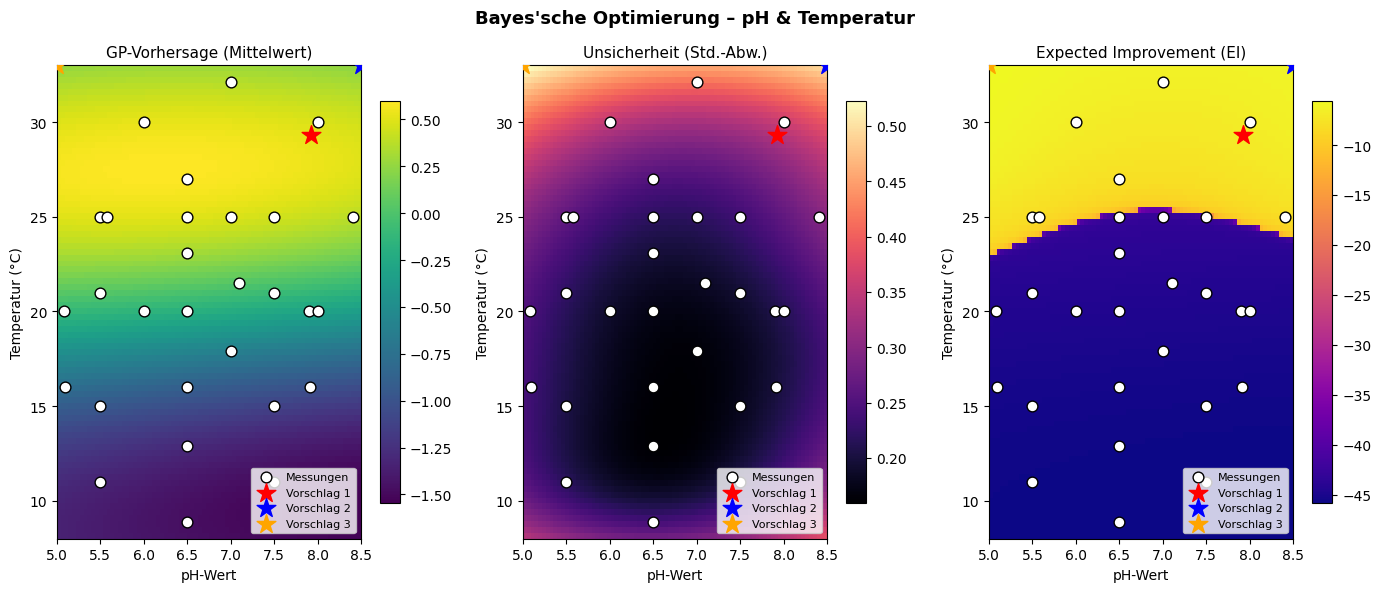

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import torch

# Auflösung des Grids
res = 80
temp_vals = torch.linspace(0, 1, res, dtype=torch.double)
ph_vals   = torch.linspace(0, 1, res, dtype=torch.double)
grid_T, grid_pH = torch.meshgrid(temp_vals, ph_vals, indexing='ij')
grid_points = torch.stack([grid_T.flatten(), grid_pH.flatten()], dim=1)

# GP-Vorhersagen
with torch.no_grad():
    posterior = model.posterior(grid_points)
    mean    = posterior.mean.reshape(res, res).numpy()
    std_dev = posterior.variance.sqrt().reshape(res, res).numpy()

# EI auf dem Grid berechnen
with torch.no_grad():
    ei_vals = acq_function(grid_points.unsqueeze(1))
    ei_map  = ei_vals.reshape(res, res).numpy()

# Rückrechnung der Achsen auf echte Einheiten
temp_axis = np.linspace(bounds_raw[0, 0].item(), bounds_raw[1, 0].item(), res)
ph_axis   = np.linspace(bounds_raw[0, 1].item(), bounds_raw[1, 1].item(), res)

fig, axes = plt.subplots(1, 3, figsize=(14, 6))
fig.suptitle("Bayes'sche Optimierung – pH & Temperatur", fontsize=13, fontweight='bold')

# Gemeinsame Plot-Hilfsfunktion mit vertauschten Achsen
def plot_heatmap(ax, data, title, cmap, xlabel=True):
    im = ax.imshow(
        data.T,
        origin='lower',
        aspect='auto',
        cmap=cmap,
        extent=[ph_axis[0], ph_axis[-1], temp_axis[0], temp_axis[-1]]
    )

    plt.colorbar(im, ax=ax, shrink=0.85)

    ax.set_title(title, fontsize=11)
    ax.set_xlabel("pH-Wert")
    ax.set_ylabel("Temperatur (°C)")

    # Bisherige Experimente einzeichnen
    X_real = copy.deepcopy(train_X_raw)

    ax.scatter(
        X_real[:, 1],   # pH -> x
        X_real[:, 0],   # Temperatur -> y
        c='white',
        edgecolors='black',
        s=60,
        zorder=5,
        label='Messungen'
    )

    # Nächste Vorschläge
    ax.scatter(
        candidate_raw[0, 1].item(),  # pH
        candidate_raw[0, 0].item(),  # Temperatur
        c='red',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 1'
    )

    ax.scatter(
        candidate_raw[1, 1].item(),
        candidate_raw[1, 0].item(),
        c='blue',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 2'
    )

    ax.scatter(
        candidate_raw[2, 1].item(),
        candidate_raw[2, 0].item(),
        c='orange',
        marker='*',
        s=200,
        zorder=6,
        label='Vorschlag 3'
    )

    ax.legend(fontsize=8, loc='lower right')

# Daten für die Plots müssen transponiert werden für korrekte Darstellung
plot_heatmap(axes[0], mean.T,    "GP-Vorhersage (Mittelwert)", 'viridis')
plot_heatmap(axes[1], std_dev.T, "Unsicherheit (Std.-Abw.)",   'magma')
plot_heatmap(axes[2], ei_map.T,  "Expected Improvement (EI)",  'plasma')

plt.tight_layout()
Path(f"../plots/{FILENAME}").mkdir(parents=True, exist_ok=True)
plt.savefig(f"../plots/{FILENAME}/bayes_opt_heatmaps.png", dpi=150, bbox_inches='tight')
plt.show()
